# Amazon Product Intelligence Assistant

## Task – Data Engineering

### Dataset Exploration & Profiling

In [2]:
# Required Imports
import pandas as pd
import numpy as np

from pathlib import Path

# To see full data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

In [3]:
DATA_DIR = Path("/home/mansoor_ali/amazon-product-intelligence/data/raw")

products_df = pd.read_csv(DATA_DIR / "products.csv")
reviews_df = pd.read_csv(DATA_DIR / "reviews.csv")

* **Products Dataset Overview**

In [4]:
# Overview
products_df.head()

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1,default_variant/2,delivery_date,fastest_delivery_date,list_price,manufacturer,model_number,price_value,product_description,product_url,rating_count,rating_distribution/1star,rating_distribution/2star,rating_distribution/3star,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
0,0,"Premium Comfort: Crafted from a high-quality cotton blend, these mens polo shirts are soft, lightweight, and breatha...",B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry) #85 in Men's Activewear Polos",MLYENX Store,https://www.amazon.com/stores/MLYENX/page/1FCDBC12-B80F-4084-A727-D6DE911CC4EB?ref_=ast_bln&store_ref=bl_ast_dp_bran...,"Clothing, Shoes & Jewelry › Men › Clothing › Active › Active Shirts & Tees › Polos","Customers find the shirts comfortable and well-fitting. They appreciate the soft, smooth material that feels very sm...",size:Large,"color:5 Pack Black, Dark Grey, Light Blue, Milddle Blue, Light Grey",NaN,"Saturday, March 15","Tomorrow, March 11",List Price: $53.99,NaN,NaN,39.9926,NaN,https://www.amazon.com/dp/B0B59BJG6Y,"1,654 ratings",2%,1%,7%,15%,75%,4.6 out of 5 stars,50+ bought,03-10-2025 21:42,Greenfive,https://www.amazon.com/gp/help/seller/at-a-glance.html/ref=dp_merchant_link?ie=UTF8&seller=A5ETY7BZYGD5S&asin=B0B59B...,4/5 Pack Mens Polo Shirts Short Sleeve Quick Dry Moisture Wicking Casual Golf T Shirts for Men,"['https://m.media-amazon.com/images/I/41yUF65PmbL.jpg', 'https://m.media-amazon.com/images/I/41jMweQcgzL.jpg', 'http...",85.0
1,1,"Material: Men's polo shirt is made of soft polyester fabric, moisture wicking, stain-resistant, durable work shirts,...",B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry) #199 in Men's Polo Shirts",COOFANDY Store,https://www.amazon.com/stores/COOFANDY/page/23614F3D-BBD9-4564-8B56-4436A5CD5A93?ref_=ast_bln&store_ref=bl_ast_dp_br...,"Clothing, Shoes & Jewelry › Men › Clothing › Shirts › Polos",NaN,size:X-Large,color:Light Grey,NaN,"Saturday, March 15","Tomorrow, March 11",Typical price: $24.99,NaN,NaN,19.9920,NaN,https://www.amazon.com/dp/B0DLGB4RYH,20 ratings,0%,6%,11%,17%,66%,4.4 out of 5 stars,NaN,03-10-2025 21:42,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-glance.html/ref=dp_merchant_link?ie=UTF8&seller=AW10J8VB8Z74G&asin=B0DLGB...,COOFANDY Men's Polo Shirts Short Sleeve Moisture Wicking Golf Shirt Fashion Casual Collared T-Shirt,"['https://m.media-amazon.com/images/I/31a3mSs3paL.jpg', 'https://m.media-amazon.com/images/I/41jqhQ7vMLL.jpg', 'http...",199.0
2,2,"PERFORMANCE:These men polo shirts are soft,lightweight and moisture wicking,keep you cool and breathableMULTIPACK:3 ...",B0DRXF62JH,In Stock,"#69,641 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry) #111 in Men's Activewear Polos",ZITY Store,https://www.amazon.com/stores/ZITY/page/F582B6FA-FA45-4D47-9B10-7296650A2718?ref_=ast_bln&store_ref=bl_ast_dp_brandL...,"Clothing, Shoes & Jewelry › Men › Clothing › Active › Active Shirts & Tees › Polos",NaN,size:X-Large,color:Bblack Grey Navy,NaN,"Saturday, March 15","Wednesday, March 12",List Price: $59.99,NaN,NaN,29.9950,NaN,https://www.amazon.com/dp/B0DRXF62JH,5 ratings,0%,0%,0%,37%,63%,4.6 out of 5 stars,NaN,03-10-2025 21:42,ZITY®,https://www.amazon.com/gp/help/seller/at-a-glance.html/ref=dp_merchant_link?ie=UTF8&seller=A26KN7P3I0WWYV&asin=B0DRX...,ZITY 3 Pack Men Polo Shirts Short Sleeve with Pocket Sport Wicking Shirts for Men Casual Athletic Collared T-Shirts,"['https://m.media-amazon.com/images/I/41J5q-Ua0KL.jpg', 'https://m.media-amazon.com/images/I/410wWdbkEzL.jpg', 'http...",111.0
3,3,"【Material】: These golf shirts for men are made of quality polyester and spandx fabric, providing you with lightweigh...",B0DK5FZ

In [5]:
# Shape of the data
products_df.shape

(728, 34)

In [6]:
# Info
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   s.no                       728 non-null    int64  
 1   about_item                 728 non-null    str    
 2   asin                       728 non-null    str    
 3   availability               715 non-null    str    
 4   best_sellers_rank          558 non-null    str    
 5   brand_name                 728 non-null    str    
 6   brand_page_url             649 non-null    str    
 7   breadcrumbs                715 non-null    str    
 8   customer_review_summary    634 non-null    str    
 9   default_variant/0          696 non-null    str    
 10  default_variant/1          658 non-null    str    
 11  default_variant/2          1 non-null      str    
 12  delivery_date              702 non-null    str    
 13  fastest_delivery_date      667 non-null    str    
 14  list_

In [7]:
# Statictics
products_df.describe(include="all")

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1,default_variant/2,delivery_date,fastest_delivery_date,list_price,manufacturer,model_number,price_value,product_description,product_url,rating_count,rating_distribution/1star,rating_distribution/2star,rating_distribution/3star,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
count,728.000000,728,728,715,558,728,649,715,634,696,658,1,702,667,401,266,199,707.000000,271,728,719,728,728,728,728,728,719,569,728,707,426,728,728,540.000000
unique,NaN,697,728,11,539,285,237,140,616,118,413,1,51,33,205,131,191,NaN,238,728,645,34,19,24,33,63,24,19,120,267,426,704,714,NaN
top,NaN,"Textured fabric that's soft, light & breathable|Material wicks sweat & dries really fast|Anti-odor technology preven...",B0B59BJG6Y,In Stock,"#67 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry) #1 in Men's Activewear Polos",Hanes Store,https://www.amazon.com/stores/Hanes/page/F83022EC-A709-4B2F-BCB7-7BBFA1896AB0?ref_=ast_bln&store_ref=bl_ast_dp_brand...,"Clothing, Shoes & Jewelry › Men › Clothing › Jeans","Customers find the shirt has a good fit and style. They appreciate the flattering shoulders, collar, and extra lengt...",size:Large,color:Black,color:Team Red/Black/Team Red Viper,"Saturday, March 15","Tomorrow, March 11",List Price: $39.99,Amazon Essentials,1290140,NaN,"We listen to customer feedback and fine-tune every detail to ensure our clothes are more comfortable, higher quality...",https://www.amazon.com/dp/B0B59BJG6Y,20 ratings,3%,2%,6%,15%,75%,4.5 out of 5 stars,100+ bought,03-10-2025 22:38,Amazon.com,https://www.amazon.com/gp/help/seller/at-a-glance.html/ref=dp_merchant_link?ie=UTF8&seller=A5ETY7BZYGD5S&asin=B0B59B...,Under Armour Men's Tech Golf Polo,"['https://m.media-amazon.com/images/I/21+XaygRfPL.jpg', 'https://m.media-amazon.com/images/I/31fTk6PXieL.jpg', 'http...",NaN
freq,NaN,3,1,640,3,35,35,52,3,168,106,1,610,491,10,21,3,NaN,8,1,4,123,194,107,89,44,131,108,18,278,1,3,2,NaN
mean,423.361264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.323948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.622222
std,293.923401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.422336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.115097
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.457300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,184.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.990000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
50%,371.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.950000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.500000
75%,553.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.771600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220.250000


In [8]:
products_df.memory_usage(deep=True).sum() / 1024**2

np.float64(1.666569709777832)

## 📊 Dataset Exploration – Products Dataset (`products.csv`)

### Dataset Overview

The `products.csv` dataset contains product-level information scraped from Amazon. Each record represents a single product and includes product metadata, descriptive text, pricing information, ratings, seller information, and various scrape-specific attributes.

| Property | Value |
|----------|-------|
| Dataset | `products.csv` |
| Rows | **728** |
| Columns | **34** |
| Memory Usage | **~1.7 MB** |
| Data Types | 31 String, 2 Float, 1 Integer |
| Candidate Primary Key | `asin` |
| Duplicate ASINs | None (728 unique products) |

---

## Initial Observations

- The dataset is relatively **small**, making it suitable for an in-memory processing pipeline using **Pandas**.
- Every product has a unique **ASIN**, which will serve as the **primary key** for the project and the join key with the `reviews.csv` dataset.
- The dataset appears to be generated from **web scraping** rather than an official Amazon catalog, meaning several columns represent scrape-time information rather than intrinsic product attributes.
- The majority of columns are textual, which is beneficial for building a Retrieval-Augmented Generation (RAG) knowledge base.

---

# Schema Classification

To simplify downstream preprocessing and document construction, columns are classified based on their intended role within the RAG system.

---

## 1. Primary Identifier

| Column | Decision | Reason |
|--------|----------|--------|
| `asin` |  Keep | Primary key and join key with reviews |
| `product_url` | Keep (Metadata) | Useful for source attribution and UI links |
| `s.no` |  Drop | Internal row identifier with no business value |

---

## 2. Core Product Content (Document Body)

These columns contain the primary semantic information that should form the textual document embedded into the vector database.

| Column | Decision | Reason |
|--------|----------|--------|
| `title` |  Keep | Strong retrieval signal |
| `about_item` |  Keep | Rich product feature list |
| `product_description` |  Keep | Detailed product description (when available) |
| `brand_name` |  Keep | Important product attribute |

---

## 3. Product Metadata

These fields are useful during retrieval and response generation but should primarily be stored as metadata rather than embedded directly into the document text.

| Column | Decision | Reason |
|--------|----------|--------|
| `price_value` |  Keep | Product price |
| `rating_stars` |  Keep | Overall rating |
| `rating_count` |  Keep | Rating confidence indicator |
| `best_sellers_rank` |  Keep | Popularity indicator |
| `breadcrumbs` |  Keep | Product category hierarchy |
| `availability` |  Keep | Inventory status |

---

## 4. Review Summary

| Column | Decision | Reason |
|--------|----------|--------|
| `customer_review_summary` |  Tentatively Keep | Will be evaluated after analyzing `reviews.csv` |

Since a separate `reviews.csv` dataset exists, the usefulness of this generated summary will be evaluated later before making a final decision.

---

## 5. Product Variants

| Column | Decision | Reason |
|--------|----------|--------|
| `default_variant/0` |  Keep | Variant information (e.g., size) |
| `default_variant/1` |  Keep | Variant information (e.g., color) |
| `default_variant/2` |  Drop | Contains only one non-null value |

---

## 6. Manufacturer Information

| Column | Decision | Reason |
|--------|----------|--------|
| `manufacturer` |  Keep | Optional manufacturer metadata |
| `model_number` |  Keep | Useful for product identification and comparisons |

---

## 7. Seller Information

| Column | Decision | Reason |
|--------|----------|--------|
| `seller_name` |  Keep | Useful metadata |
| `seller_page_url` |  Drop | Not useful for retrieval |
| `brand_page_url` |  Drop | External navigation link |

---

## 8. Delivery Information

| Column | Decision | Reason |
|--------|----------|--------|
| `delivery_date` |  Drop | Time-dependent scrape information |
| `fastest_delivery_date` |  Drop | Time-dependent scrape information |

These values become stale quickly and do not contribute to semantic retrieval.

---

## 9. Rating Distribution

| Column | Decision | Reason |
|--------|----------|--------|
| `rating_distribution/1star` |  Keep | Customer sentiment metadata |
| `rating_distribution/2star` |  Keep | Customer sentiment metadata |
| `rating_distribution/3star` |  Keep | Customer sentiment metadata |
| `rating_distribution/4star` |  Keep | Customer sentiment metadata |
| `rating_distribution/5star` |  Keep | Customer sentiment metadata |

These fields may help answer questions regarding customer satisfaction and rating distribution.

---

## 10. Other Columns

| Column | Decision | Reason |
|--------|----------|--------|
| `list_price` |  Keep | Optional pricing metadata |
| `recent_purchases` |  Keep | Popularity indicator |
| `all_images` |  Drop | Image URLs are outside the scope of this text-based RAG system |
| `scrape_time` |  Drop | Operational metadata only |
| `rank_1` |  Investigate | Requires further understanding of its meaning |

---

# Missing Value Analysis

Several columns contain a significant number of missing values.

| Column | Non-Null Count | Missing (%) | Initial Decision |
|---------|---------------:|------------:|------------------|
| `product_description` | 271 | **62.8%** | Keep; fallback to `about_item` when missing |
| `manufacturer` | 266 | **63.5%** | Optional metadata |
| `model_number` | 199 | **72.7%** | Keep if available |
| `list_price` | 401 | **44.9%** | Optional metadata |
| `default_variant/2` | 1 | **99.9%** | Drop |

---

# Initial RAG Document Design

Based on the current analysis, each product document is expected to contain information similar to the following:

```text
Product:
Under Armour Men's Tech Golf Polo

Brand:
Under Armour

Category:
Clothing > Men > Shirts

Price:
$39.99

Average Rating:
4.5 / 5

About:
...

Description:
...

Customer Review Summary:
...
```

Structured attributes such as `asin`, `price_value`, `rating_count`, and `breadcrumbs` will likely be stored as **metadata** within the vector database rather than embedded into the document text.

---

# Preliminary Conclusions

- `products.csv` will serve as the **primary source of product knowledge** for the RAG system.
- The **ASIN** will be adopted as the canonical product identifier throughout the project.
- Product information should be divided into **document content** and **retrieval metadata** to improve retrieval quality and maintain a clean document structure.
- Final decisions regarding review summaries and document composition will be made after analyzing the `reviews.csv` dataset.
- The preprocessing pipeline should be designed to handle missing values gracefully, especially for optional descriptive fields such as `product_description`.

* **Reviews Dataset Overview**

In [9]:
reviews_df.head()

,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,productASIN,productVariant,rating,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DLGB4RYH,Color: BlackSize: X-Large,5.0,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,"‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fantastic blend of style, comfort, and affordability, making it a great ch...",Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style comfort affordability making great choice casual smartcasual occasion ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Bblack Grey NavySize: 3X-Large,5.0,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,"I love these. They look good. They fit well. They are comfortable, breathable and are just a no brainer when I am th...",New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable brainer thinking wear work even button collar feel gaged well done ev...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Grey Navy DuckblueSize: Medium,4.0,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, 2025",2,My expectations were low -- how good could shirts that sell 3 for $30 be? No one will mistake these for an expensiv...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mistake expensive designer shirt shocked pleasantly pleased nice shirt mon...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Black Duckblue WineredSize: X-Large,5.0,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, 2025",3,This 3-pack of multi-color shirts is really a no brainer if you wear this type of shirt and prefer your shirt on the...,Higher quality & breathable 3-pack shirt set that is at an outstanding price point!,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type shirt prefer shirt breathable sidei chose multicolor wine shirt part ...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Bblack Grey NavySize: X-Large,5.0,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, 2025",4,"With these three polo shirts I was very satisfied with the quality of the material, which is very good, offering unm...",Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material good offering unmatched comfort thanks soft interior three different col...,0.250000


In [10]:
reviews_df.shape

(6327, 23)

In [11]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6327 entries, 0 to 6326
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   s.no                 6327 non-null   int64  
 1   helpfulVoteCount     6327 non-null   int64  
 2   images/0             516 non-null    str    
 3   images/1             212 non-null    str    
 4   images/2             98 non-null     str    
 5   images/3             49 non-null     str    
 6   images/4             26 non-null     str    
 7   images/5             14 non-null     str    
 8   images/6             7 non-null      str    
 9   images/7             5 non-null      str    
 10  productASIN          6327 non-null   str    
 11  productVariant       5836 non-null   str    
 12  rating               6320 non-null   float64
 13  reviewID             6327 non-null   str    
 14  reviewMetadata       6296 non-null   str    
 15  reviewPosition       6327 non-null   int64  
 16 

In [12]:
reviews_df.describe(include="all")

,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,productASIN,productVariant,rating,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
count,6327.000000,6327.000000,516,212,98,49,26,14,7,5,6327,5836,6320.000000,6327,6296,6327.000000,6289,6313,6327,6327,34,6288,6327.000000
unique,NaN,NaN,516,212,98,49,26,14,7,5,700,4923,NaN,6327,774,NaN,6232,5162,6327,2,34,6182,NaN
top,NaN,NaN,https://m.media-amazon.com/images/I/71GGhK1wV2L._SY500.jpg,https://m.media-amazon.com/images/I/71Yvo1YGHAL._SY500.jpg,https://m.media-amazon.com/images/I/71a2r0M0ysL._SY500.jpg,https://m.media-amazon.com/images/I/81ffRqqWETL._SY500.jpg,https://m.media-amazon.com/images/I/71eJV1IjjBL._SY500.jpg,https://m.media-amazon.com/images/I/71npNe8RtsL._SY500.jpg,https://m.media-amazon.com/images/I/71rsqJ7cewL._SY500.jpg,https://m.media-amazon.com/images/I/71yMEj41FEL._SY500.jpg,B074KL8RVS,Size: MediumColor: Black,NaN,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",NaN,Excelente,Comfortable,https://www.amazon.com/review/R2AUQFPJY5ERCZ,True,https://m.media-amazon.com/images/I/D1MrqEYXafL.mp4,good,NaN
freq,NaN,NaN,1,1,1,1,1,1,1,1,19,31,NaN,1,154,NaN,8,64,1,6167,1,13,NaN
mean,5803.484748,3.336336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.533228,NaN,NaN,5.374743,NaN,NaN,NaN,NaN,NaN,NaN,0.307545
std,3833.648255,19.090762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.855710,NaN,NaN,2.889921,NaN,NaN,NaN,NaN,NaN,NaN,0.218020
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000
25%,2103.500000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.168568
50%,5969.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.300000
75%,7572.500000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.450000


# 📊 Dataset Exploration – Reviews Dataset (`reviews.csv`)

## Dataset Overview

The `reviews.csv` dataset contains customer review information for Amazon products. Each record represents a single customer review associated with a specific product through the `productASIN` field.

| Property | Value |
|----------|-------|
| Dataset | `reviews.csv` |
| Rows | **6,327** |
| Columns | **23** |
| Memory Usage | **~5.5 MB** |
| Data Types (Pandas Inferred) | 17 String, 3 Integer, 2 Float, 1 Boolean |
| Candidate Primary Key | `reviewID` |
| Foreign Key | `productASIN` → `products.asin` |

---

# Initial Observations

- Each row represents **one customer review** rather than one product.
- The dataset contains **6,327 reviews** distributed across **700 unique products**.
- Reviews are linked to products using the **productASIN** column.
- Compared to the product dataset, this dataset provides significantly richer natural language content, making it one of the primary knowledge sources for the RAG system.
- Most reviews are verified purchases, increasing the reliability of the dataset.

---

# Important Engineering Finding – Logical Schema

Unlike `products.csv`, this dataset already contains several machine-friendly data types.

Examples:

| Column | Pandas Type | Logical Type | Remarks |
|---------|-------------|--------------|---------|
| `rating` | Float | Float | Already normalized |
| `helpfulVoteCount` | Integer | Integer | Already normalized |
| `verifiedPurchase` | Boolean | Boolean | Already normalized |
| `sentiment_score` | Float | Float | Precomputed sentiment score |

However, several columns still represent structured information stored as plain text.

Examples:

| Column | Current Type | Logical Interpretation |
|---------|--------------|-----------------------|
| `reviewMetadata` | String | Review Date + Country |
| `productVariant` | String | Variant Attributes (Color, Size, etc.) |
| `reviewText` | String | Natural Language Document |
| `reviewTitle` | String | Review Summary |

These fields may require additional parsing during preprocessing.

---

# Schema Classification

---

## 1. Primary Identifier

| Column | Decision | Reason |
|---------|----------|--------|
| `reviewID` | Keep | Unique identifier for each review |
| `productASIN` |  Keep | Foreign key linking reviews to products |
| `s.no` |  Drop | Internal row identifier |

---

## 2. Core Review Content (Highest Priority)

These fields contain the semantic information that contributes most to Retrieval-Augmented Generation.

| Column | Decision | Reason |
|---------|----------|--------|
| `reviewTitle` |  Keep | Concise review summary |
| `reviewText` | Keep | Primary review content |
| `cleaned_review_text` |  Investigate | May be useful for NLP preprocessing but not necessarily for LLM retrieval |

At this stage, the original review text is preferred over the cleaned version because punctuation and natural language structure generally improve readability for LLMs.

---

## 3. Review Metadata

These fields provide useful context but are not the primary semantic content.

| Column | Decision | Reason |
|---------|----------|--------|
| `rating` |  Keep | Customer rating |
| `verifiedPurchase` |  Keep | Trust indicator |
| `helpfulVoteCount` |  Keep | Review usefulness |
| `reviewPosition` |  Keep | Indicates ordering on Amazon |
| `reviewMetadata` |  Investigate | Contains review location and date |
| `productVariant` |  Keep | Product variant information |

---

## 4. Media Fields

| Column | Decision | Reason |
|---------|----------|--------|
| `images/0` - `images/7` |  Drop | Images are outside the scope of this text-based RAG system |
| `videos/0` |  Drop | Videos are outside the project scope |

---

## 5. URLs

| Column | Decision | Reason |
|---------|----------|--------|
| `reviewURL` |  Drop | External navigation URL |

---

## 6. Sentiment Information

| Column | Decision | Reason |
|---------|----------|--------|
| `sentiment_score` |  Keep | Useful analytical feature; final decision pending document design |

Although the sentiment score may not improve semantic retrieval directly, it could support future analytics and evaluation tasks.

---

# Missing Value Analysis

Several columns contain significant numbers of missing values.

| Column | Non-Null Count | Missing (%) | Initial Decision |
|---------|---------------:|------------:|------------------|
| `images/0` | 516 | 91.8% | Drop |
| `images/1` | 212 | 96.6% | Drop |
| `images/2` | 98 | 98.5% | Drop |
| `videos/0` | 34 | 99.5% | Drop |
| `cleaned_review_text` | 6288 | 0.6% | Investigate |
| `reviewText` | 6289 | 0.6% | Keep |
| `reviewTitle` | 6313 | 0.2% | Keep |

The review content itself is nearly complete, indicating high data quality for downstream RAG processing.

---

# Preliminary Insights

Several observations stand out from the review dataset:

- The dataset is significantly larger than the products dataset (6,327 reviews vs. 728 products).
- Approximately **700 products** have associated reviews, meaning not every product in `products.csv` necessarily has review data, 1 product has multiple reviews.
- The relationship between the two datasets is **one-to-many (1:N)**:
- One product (`products.csv`) can have **multiple reviews** (`reviews.csv`).
- Each review belongs to **exactly one product**, identified by the `productASIN` foreign key.
- Reviews provide the richest source of natural language information and will play a major role in the knowledge base.
- The presence of a precomputed `sentiment_score` suggests the dataset has undergone previous NLP processing, although the usefulness of this field for the RAG pipeline remains to be evaluated.

---

# Preliminary Conclusions

- `reviews.csv` will serve as the **primary customer opinion source** within the knowledge base.
- `reviewID` will act as the unique identifier for reviews.
- `productASIN` establishes the relationship between products and reviews.
- Media-related fields (images and videos) fall outside the scope of the MVP and will be excluded.
- Final decisions regarding review aggregation, document composition, and review selection will be made after completing the relationship analysis between `products.csv` and `reviews.csv`.

---

# Relationship Analysis

1. Referential Integrity
* Do all reviews belong to an existing product?
* Are there orphan reviews?
* Are there products without reviews?

In [13]:
# Unique Products
print(f"Number of products in products dataset: {products_df['asin'].nunique()}")
print(f"Number of products in reviews dataset: {reviews_df['productASIN'].nunique()}")  

Number of products in products dataset: 728
Number of products in reviews dataset: 700


In [14]:
# Products with no reviewa
products_without_reviews = (
    set(products_df["asin"])
    - set(reviews_df["productASIN"])
)

print(f"Number of products with no reviews: {len(products_without_reviews)}")

Number of products with no reviews: 28


In [15]:
# Orphan Reviews
orphan_reviews = (
    set(reviews_df["productASIN"])
    - set(products_df["asin"])
)

print(f"Number of orphan reviews: {len(orphan_reviews)}")

Number of orphan reviews: 0


# Interpretation

* This is a very healthy relational dataset.

- Every review references a valid product.
- There are no orphan records, meaning referential integrity is preserved.
- Only 3.85% of products lack reviews, which is acceptable for this project.


---
2. Relationship Cardinality
* Is the relationship truly 1:N?
* Average reviews per product.
* Maximum reviews per product.
* Distribution of reviews.

In [16]:
# Reviews per product
reviews_per_product = (
    reviews_df
    .groupby("productASIN",)
    .size()
)
print(f"Number of products with reviews: {reviews_per_product.shape[0]}")

Number of products with reviews: 700


In [17]:
# Basic Stats
reviews_per_product.describe()

count    700.000000
mean       9.038571
std        2.687319
min        1.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       19.000000
dtype: float64

In [18]:
# Top 10 products with most reviews
reviews_per_product.sort_values(
    ascending=False
).head(10)

print(f"Top 10 products with most reviews: {reviews_per_product.sort_values(ascending=False).head(10)}")

Top 10 products with most reviews: productASIN
B074KL8RVS    19
B07HR877BN    14
B074KL2SHP    14
B08Q86H92W    13
B07DRMT92L    13
B09Q618MMY    12
B098QPTCF8    12
B08GZL48D9    12
B09JFZTWVJ    12
B00NOY3JKW    12
dtype: int64



In [19]:
# Bottom 10 products with least reviews
reviews_per_product.sort_values().head(10)

productASIN
B0DS6141ZT    1
B00GZIT5A2    1
B0DK5FZ325    1
B0DLGB4RYH    1
B01BDZMIK0    1
B0CSG34RQS    1
B0D1H1HV5F    1
B0D8198XHF    1
B0CSJ417P3    1
B0CPF94HN3    1
dtype: int64

## Interpretation

### Statistics

| Metric | Value |
|--------|------:|
| Products with Reviews | 700 |
| Total Reviews | 6,327 |
| Average Reviews per Product | **9.04** |
| Median Reviews per Product | **10** |
| Minimum Reviews | **1** |
| Maximum Reviews | **19** |


The analysis confirms a **true One-to-Many (1:N) relationship** between the **Products** and **Reviews** datasets.

```text
        1 Product
            │
            ▼
      1–19 Reviews
```

Each product can have multiple reviews, while every review belongs to exactly one product. This relationship makes the reviews table a child entity of the products table and validates the expected relational design.

### Implications

- ✔ Confirms a valid **1:N relational structure** between Products and Reviews.
- ✔ Reviews can be safely joined with products using the product identifier.
- ✔ Low variance in review counts minimizes bias toward highly reviewed products.
- ✔ Suitable for exploratory data analysis, recommendation experiments, and product-level sentiment analysis without requiring heavy normalization for review volume.
---
## Top Products Analysis ✅

### Statistics

| Metric | Value |
|--------|------:|
| Maximum Reviews | **19** |
| Minimum Reviews | **1** |

The product with the highest number of reviews has **19 reviews**, while the lowest has **1 review**.

No extreme outliers are present, indicating a balanced review distribution across products. This reduces popularity bias and makes the dataset suitable for fair product-level analysis.

---
3. Coverage Analysis
* Percentage of products having reviews.
* Percentage without reviews.


In [20]:
# Percentage of products having reviews
coverage = (
    reviews_df["productASIN"].nunique()
    / products_df["asin"].nunique()
) * 100

print(f"Percentage of products having reviews: {coverage:.2f}%")


# Producrs with no reviews
no_review_coverage = 100 - coverage
print(f"Percentage of products with no reviews: {no_review_coverage:.2f}%")

Percentage of products having reviews: 96.15%
Percentage of products with no reviews: 3.85%


## Interpretation

### Statistics

| Metric | Value |
|--------|------:|
| Products with Reviews | **96.15%** |
| Products without Reviews | **3.85%** |


The coverage analysis shows that **96.15% of products have at least one associated review**, while only **3.85%** of products do not contain review data.

The high review coverage is particularly valuable for **Retrieval-Augmented Generation (RAG)** systems because customer reviews typically contain the richest semantic information about a product. Reviews capture real user experiences, opinions, advantages, limitations, and practical usage scenarios that are often absent from structured product metadata.

Only a small fraction of products (approximately **28 products**) lack review information. For these products, the product title, description, specifications, and other metadata can still be indexed as standalone documents, ensuring that they remain searchable within the retrieval system.

The minimal amount of missing review data means that additional preprocessing or complex handling strategies are unnecessary, simplifying downstream pipeline development.

---
4. Document Design Inputs
* Should we create one document per product?
* One document per review?
* Or aggregate reviews into the product document?

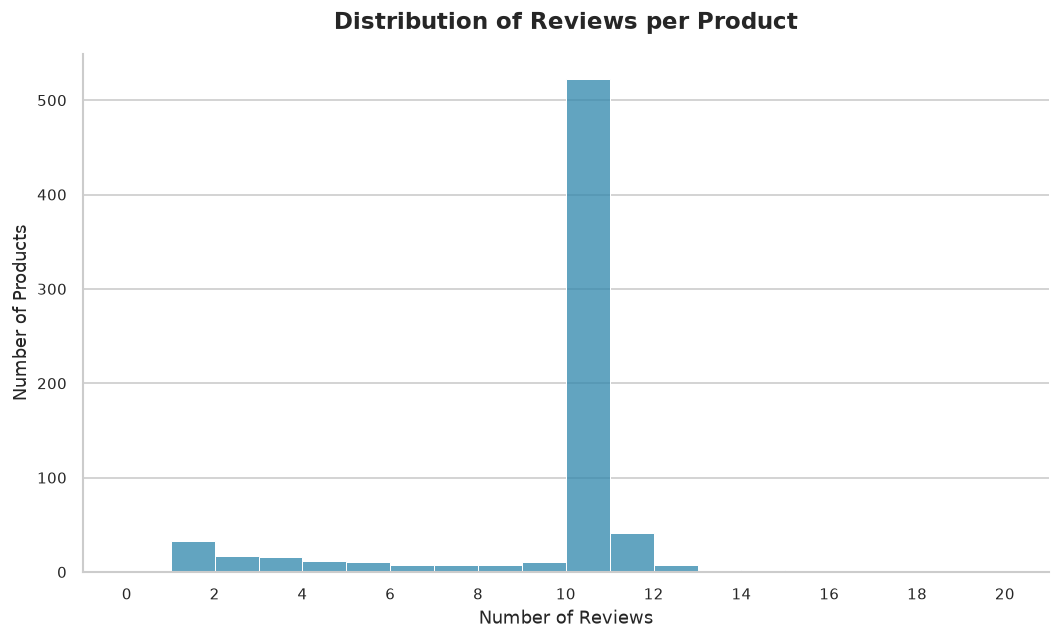

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

sns.histplot(
    reviews_per_product,
    bins=range(0, int(reviews_per_product.max()) + 2),  # integer bins, no split bars
    color='#2E86AB',
    edgecolor='white',
    linewidth=0.6,
    ax=ax
)

ax.set_title('Distribution of Reviews per Product', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_ylabel('Number of Products', fontsize=11)

ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=9)
ax.grid(axis='x', visible=False)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('reviews_per_product.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Relationship verification
reviews_per_product.max()

np.int64(19)

# Interpretation

### Statistics

| Metric | Value |
|--------|------:|
| Most Common Review Count | **~10 Reviews** |
| Review Count Range | **1–19 Reviews** |

---

The review distribution is centered around **10 reviews per product**, with very few products having significantly fewer or more reviews.

This suggests the dataset was **sampled or curated**, rather than containing every available Amazon review. The balanced distribution makes it suitable for exploratory analysis and RAG experiments while avoiding bias toward highly reviewed products.

---
# Measure Document Size

Objective

Estimate the size of each final document after merging:

- Product Information
- About Item
- Product Description
- Customer Review Summary (if kept)
- All Reviews
- Review Titles

We want to answer:

- Average document length
- Maximum document length
- Minimum document length
- Token estimation
- Whether chunking will be necessary

In [23]:
# Create a Prototype Document

import pandas as pd

# Aggregate reviews for each product
reviews_grouped = (
    reviews_df
    .groupby("productASIN")
    .apply(
        lambda x: "\n\n".join(
            (
                "Review Title: " + x["reviewTitle"].fillna("") +
                "\nReview: " + x["reviewText"].fillna("")
            )
        )
    )
    .reset_index(name="all_reviews")
)

# Merge with products
merged_df = products_df.merge(
    reviews_grouped,
    left_on="asin",
    right_on="productASIN",
    how="left"
)

In [25]:
# Build Prototype Document

def build_document(row):
    return f"""
Product:
{row['title']}

Brand:
{row['brand_name']}

Category:
{row['breadcrumbs']}

Price:
{row['price_value']}

Rating:
{row['rating_stars']}

Availability:
{row['availability']}

About:
{row['about_item']}

Description:
{row['product_description']}

Customer Review Summary:
{row['customer_review_summary']}

Customer Reviews:
{row['all_reviews']}
"""


merged_df["document"] = merged_df.apply(
    build_document,
    axis=1
)

In [ ]:
# Character count of the document
print(f"Character Count of the document for the first product: {merged_df['char_count'].iloc[0]}")

Character Count of the document for the first product: 5116


In [31]:
# Word count of the document
merged_df["word_count"] = merged_df["document"].apply(lambda x: len(str(x).split()))
print(f"Word Count of the document for the first product: {merged_df['word_count'].iloc[0]}")

Word Count of the document for the first product: 837


In [34]:
# Approximate Token Count
merged_df["estimated_tokens"] = (
    merged_df["char_count"] / 4
).astype(int)

print(f"Estimated Token Count of the document for the first product: {merged_df['estimated_tokens'].iloc[0]}")

Estimated Token Count of the document for the first product: 1279


In [35]:
# Stats
merged_df[
    [
        "char_count",
        "word_count",
        "estimated_tokens"
    ]
].describe()

,char_count,word_count,estimated_tokens
count,728.000000,728.000000,728.000000
mean,4717.383242,807.218407,1178.987637
std,2604.446093,464.701579,651.097337
min,387.000000,58.000000,96.000000
25%,3048.000000,507.250000,761.750000
50%,4293.500000,732.000000,1073.000000
75%,5863.000000,1017.250000,1465.250000
max,22230.000000,3869.000000,5557.000000


In [36]:
# Largest Document
merged_df[
    [
        "asin",
        "title",
        "word_count",
        "estimated_tokens"
    ]
].sort_values(
    "estimated_tokens",
    ascending=False
).head(10)

,asin,title,word_count,estimated_tokens
122,B0018ON68A,Levi's Men's 501 Original Fit Jeans (Also Available in Big & Tall),3869,5557
259,B00EUHD56A,Legendary Whitetails Journeyman Shirt Jacket Flannel Lined Shacket for Men Water-Resistant Coat Rugged Fall Clothing,3308,4573
107,B0007CKJSY,Wrangler Men's 13MWZ Cowboy Cut Original Fit Jeans,2649,3664
425,B000W93PX8,Rockport Men's Eureka Walking Shoe,2439,3480
428,B01IA6CJ36,Skechers Men's Cankton Steel Toe Construction Shoe,2448,3438
65,B07DRMT92L,Real Essentials 5 Pack: Men’s Short Sleeve Dry Fit Active Crew Neck T Shirt - Athletic Running Gym Workout Tee Tops,2366,3392
78,B071WY2Q29,"Amazon Essentials Men's Crew Neck T-Shirts, Pack of 6, Versatile Basics,",2299,3357
271,B0792XJHZL,TACVASEN Men's Special Ops Military Tactical Rain Jackets Winter Warm Fleece Softshell Hooded Raincoat Snowboard,2411,3333
143,B0006U6C0Q,Wrangler Men's Cowboy Cut Slim Fit Jeans,2372,3256
705,B07J31WFNB,Amazon Essentials Skinny Jeans for Women (Stretchy),2399,3185


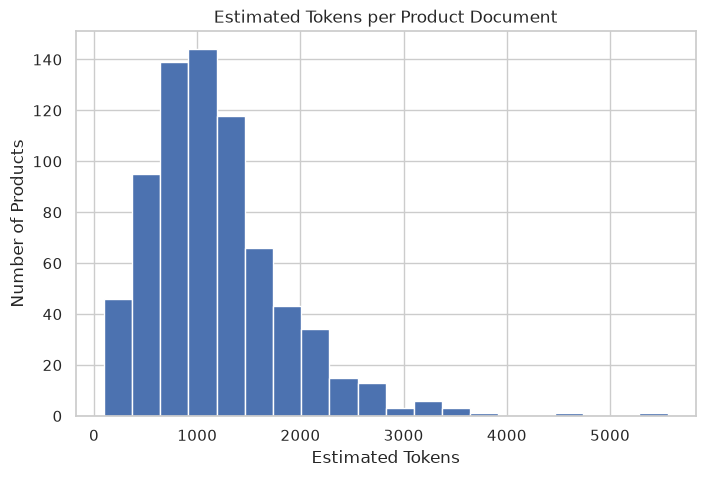

In [38]:
# Distribution of Estimated Tokens
import matplotlib.pyplot as plt

merged_df["estimated_tokens"].hist(
    bins=20,
    figsize=(8,5)
)

plt.title("Estimated Tokens per Product Document")
plt.xlabel("Estimated Tokens")
plt.ylabel("Number of Products")
plt.savefig('Estimated Tokens per Product Document', dpi=200, bbox_inches='tight')
plt.show()

## Document Size Analysis Findings

### Summary Statistics

| Metric | Value |
|--------|------:|
| Documents | **728** |
| Mean Tokens | **1,179** |
| Median Tokens | **1,073** |
| 75th Percentile | **1,465** |
| Minimum Tokens | **96** |
| Maximum Tokens | **5,557** |

---

## Key Findings

- **Most documents contain around 1,000–1,500 tokens**, making them an ideal size for RAG retrieval and LLM processing.

- **The majority of documents (≈90–95%) are under 2,000 tokens**, indicating a consistent document size across the dataset.

- **A small number of long documents (up to 5,557 tokens) exist**, but these are rare outliers rather than the norm.

- **Longer documents belong to popular products** (e.g., Levi's Jeans, Wrangler Jeans, Skechers Shoes, Amazon Essentials), likely due to richer descriptions and more detailed customer reviews.

### Interpretation

The document corpus has a **well-balanced token distribution** with only a few long-tail outliers. Overall, the dataset is well-suited for document indexing, semantic search, and Retrieval-Augmented Generation (RAG) with minimal chunking requirements.